In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("DAY 1: Predictive Maintenance - EDA")
print("=" * 50)
print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


DAY 1: Predictive Maintenance - EDA
All libraries imported successfully!


In [2]:
column_names = ['engine_id', 'cycle'] + \
               [f'sensor_{i}' for i in range(1, 22)] + \
               [f'setting_{i}' for i in range(1, 4)]

df = pd.read_csv('../data/train_FD001.txt', sep=' ', header=None)
df = df.iloc[:, :26]
df.columns = column_names

print(f"Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded!
Shape: (20631, 26)

First 5 rows:


,engine_id,cycle,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,setting_1,setting_2,setting_3
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
print(f"Total engines: {df['engine_id'].nunique()}")
print(f"Max cycles: {df.groupby('engine_id')['cycle'].max().max()}")
print(f"Min cycles: {df.groupby('engine_id')['cycle'].max().min()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

Total engines: 100
Max cycles: 362
Min cycles: 128

Missing values: 0


In [4]:
# CELL 4: Calculate RUL (Remaining Useful Life)
# Each engine runs until failure. The last cycle = failure.
# RUL = max_cycle - current_cycle

# Find max cycle for each engine (this is when it fails)
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge back to original dataframe
df = df.merge(max_cycles, on='engine_id', how='left')

# Calculate RUL
df['RUL'] = df['max_cycle'] - df['cycle']

print("RUL calculated successfully!")
print(f"\nSample of engine 1 (first 10 rows):")
print(df[df['engine_id'] == 1][['engine_id', 'cycle', 'max_cycle', 'RUL']].head(10))

print(f"\nSample of engine 1 (last 10 rows - near failure):")
print(df[df['engine_id'] == 1][['engine_id', 'cycle', 'max_cycle', 'RUL']].tail(10))

print(f"\nRUL statistics:")
print(df['RUL'].describe())

RUL calculated successfully!

Sample of engine 1 (first 10 rows):
   engine_id  cycle  max_cycle  RUL
0          1      1        192  191
1          1      2        192  190
2          1      3        192  189
3          1      4        192  188
4          1      5        192  187
5          1      6        192  186
6          1      7        192  185
7          1      8        192  184
8          1      9        192  183
9          1     10        192  182

Sample of engine 1 (last 10 rows - near failure):
     engine_id  cycle  max_cycle  RUL
182          1    183        192    9
183          1    184        192    8
184          1    185        192    7
185          1    186        192    6
186          1    187        192    5
187          1    188        192    4
188          1    189        192    3
189          1    190        192    2
190          1    191        192    1
191          1    192        192    0

RUL statistics:
count    20631.000000
mean       107.807862
std     

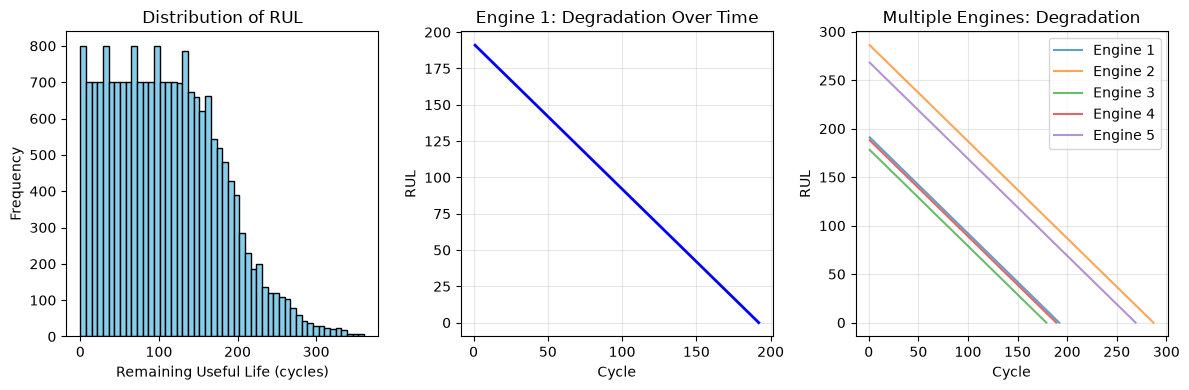


Key insight: All engines start healthy (high RUL) and degrade to 0 (failure).


In [5]:
# CELL 5: Visualize RUL distribution
plt.figure(figsize=(12, 4))

# Plot 1: Histogram of all RUL values
plt.subplot(1, 3, 1)
plt.hist(df['RUL'], bins=50, edgecolor='black', color='skyblue')
plt.xlabel('Remaining Useful Life (cycles)')
plt.ylabel('Frequency')
plt.title('Distribution of RUL')

# Plot 2: One engine's degradation over time
plt.subplot(1, 3, 2)
engine_1 = df[df['engine_id'] == 1]
plt.plot(engine_1['cycle'], engine_1['RUL'], 'b-', linewidth=2)
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title('Engine 1: Degradation Over Time')
plt.grid(True, alpha=0.3)

# Plot 3: Multiple engines comparison
plt.subplot(1, 3, 3)
for engine_id in [1, 2, 3, 4, 5]:
    engine_data = df[df['engine_id'] == engine_id]
    plt.plot(engine_data['cycle'], engine_data['RUL'], label=f'Engine {engine_id}', alpha=0.7)
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title('Multiple Engines: Degradation')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey insight: All engines start healthy (high RUL) and degrade to 0 (failure).")

Top 10 sensors most correlated with RUL:
sensor_14    0.696228
sensor_7     0.678948
sensor_15    0.671983
sensor_10    0.657223
sensor_18    0.642667
setting_3    0.635662
setting_2    0.629428
sensor_5     0.606484
sensor_20    0.606154
sensor_6     0.584520
Name: RUL, dtype: float64


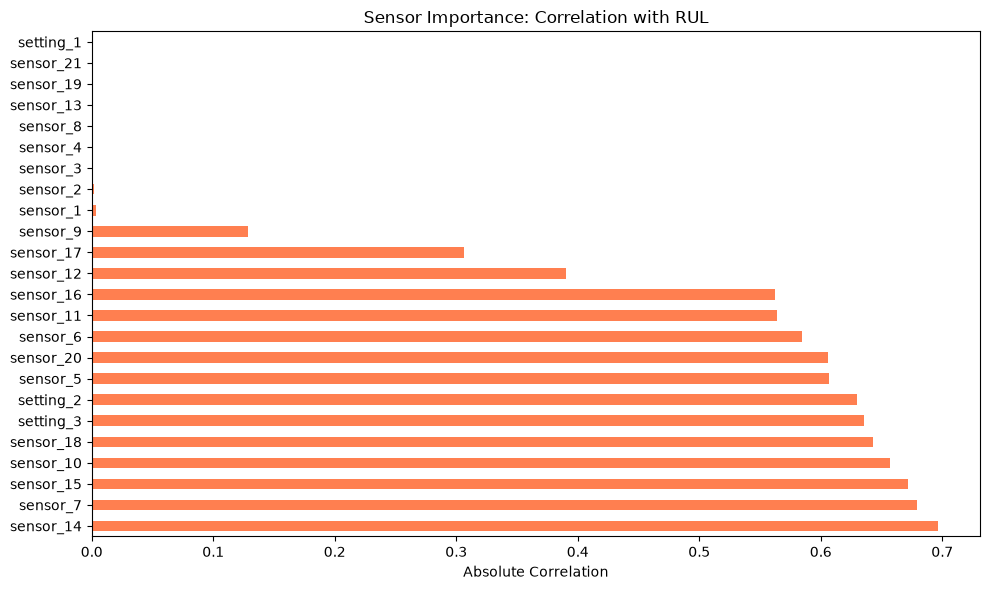


These top sensors will be our features for the model.


In [6]:
# CELL 6: Which sensors are most correlated with RUL?
# Higher absolute correlation = more important for prediction

# Drop non-sensor columns for correlation
sensor_cols = [col for col in df.columns if 'sensor' in col or 'setting' in col]
correlations = df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL')

# Sort by absolute correlation
correlations_abs = correlations.abs().sort_values(ascending=False)

print("Top 10 sensors most correlated with RUL:")
print(correlations_abs.head(10))

# Visualize
plt.figure(figsize=(10, 6))
correlations_abs.plot(kind='barh', color='coral')
plt.title('Sensor Importance: Correlation with RUL')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

print("\nThese top sensors will be our features for the model.")

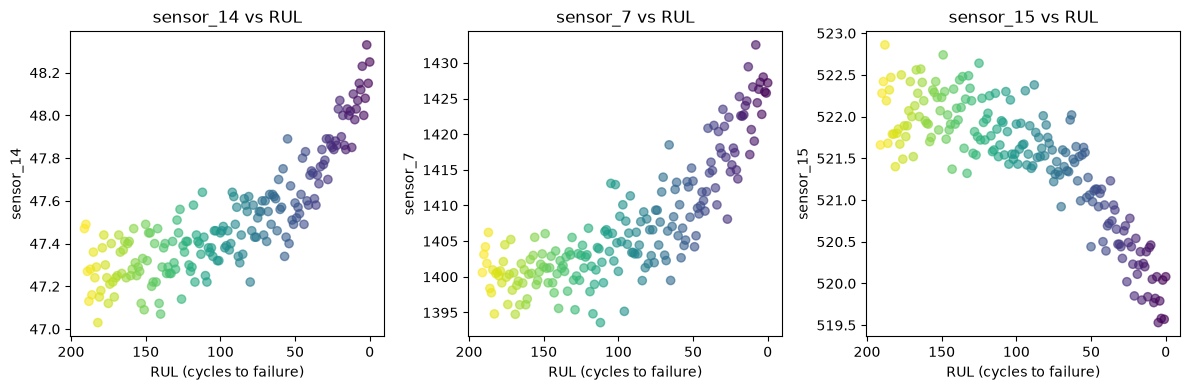

Insight: As RUL decreases (engine near failure), sensor values change.
This pattern is what our model will learn to predict.


In [7]:
# CELL 7: Watch how top sensors change as engine degrades
top_3_sensors = correlations_abs.head(3).index.tolist()

plt.figure(figsize=(12, 4))

for i, sensor in enumerate(top_3_sensors, 1):
    plt.subplot(1, 3, i)
    engine_1 = df[df['engine_id'] == 1]
    plt.scatter(engine_1['RUL'], engine_1[sensor], alpha=0.6, c=engine_1['RUL'], cmap='viridis')
    plt.xlabel('RUL (cycles to failure)')
    plt.ylabel(sensor)
    plt.title(f'{sensor} vs RUL')
    plt.gca().invert_xaxis()  # RUL decreases left to right

plt.tight_layout()
plt.show()

print("Insight: As RUL decreases (engine near failure), sensor values change.")
print("This pattern is what our model will learn to predict.")

In [8]:
# CELL 8: Save processed data for tomorrow
# Select only useful columns (drop constant/empty sensors)

# Find sensors with zero variance (constant values, useless)
constant_sensors = []
for col in sensor_cols:
    if df[col].nunique() <= 1:
        constant_sensors.append(col)

print(f"Constant sensors (will be removed): {constant_sensors}")

# Keep only useful features
useful_cols = ['engine_id', 'cycle'] + [c for c in sensor_cols if c not in constant_sensors] + ['RUL']
df_clean = df[useful_cols].copy()

print(f"\nClean dataset shape: {df_clean.shape}")
print(f"Columns kept: {df_clean.columns.tolist()}")

# Save to processed folder
import os
os.makedirs('../data/processed', exist_ok=True)
df_clean.to_csv('../data/processed/train_clean.csv', index=False)

print("\n✅ DAY 1 COMPLETE!")
print("Clean data saved to: data/processed/train_clean.csv")
print("\nWhat we learned:")
print("- 100 engines, each runs until failure")
print("- RUL = target variable (cycles until failure)")
print("- Top sensors correlate strongly with RUL")
print("- Tomorrow: Train ML model to predict RUL")

Constant sensors (will be removed): ['sensor_3', 'sensor_4', 'sensor_8', 'sensor_13', 'sensor_19', 'sensor_21', 'setting_1']

Clean dataset shape: (20631, 20)
Columns kept: ['engine_id', 'cycle', 'sensor_1', 'sensor_2', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_20', 'setting_2', 'setting_3', 'RUL']

✅ DAY 1 COMPLETE!
Clean data saved to: data/processed/train_clean.csv

What we learned:
- 100 engines, each runs until failure
- RUL = target variable (cycles until failure)
- Top sensors correlate strongly with RUL
- Tomorrow: Train ML model to predict RUL
